# Come l'evoluzione della società ha ridisegnato il mondo degli anime

Il database di MyAnimeList raccoglie 28.955 anime, oltre 337.000 utenti e più di 124 milioni di valutazioni. Analizzati nel tempo, questi dati mostrano come il mercato sia cambiato dagli anni '90, chi guarda cosa, e perché.

 Quattro domande guidano l'analisi:
  - La composizione della produzione anime è davvero cambiata, e quando?
  - Uomini e donne guardano cose così diverse?
  - Ogni generazione ha i suoi anime?
  - La geografia predice il consumo?

 Cominciamo con l'import delle librerie e il caricamento dei dataset. Per questa analisi useremo i seguenti datasets:
 - **details**: contiene le informazioni di ogni anime come titolo, generi, anno di uscita, score, members e favorites
  - **profiles**: raccoglie i dati degli utenti registrati come genere, anno di nascita e paese.
  - **ratings**: è il dataset più grande, con oltre 124 milioni di valutazioni che collegano utenti e anime.

  Da details costruiamo **details_ex**, una versione esplosa per genere che useremo in tutto il
  notebook per aggregare i dati per categoria.

In [ ]:

from solutions.storytelling.evoluzione_charts import *

DATA_PATH = '../../datasets_cleaned/'
details  = pd.read_csv(DATA_PATH + 'details_clean.csv')   # titolo, generi, anno, score, members, favorites
profiles = pd.read_csv(DATA_PATH + 'profiles_clean.csv')  # username, gender, birthday, location
ratings  = pd.read_csv(DATA_PATH + 'ratings_clean.csv')   # username, anime_id, score, status

print('details: ', details.shape)
print('profiles:', profiles.shape)
print('ratings: ', ratings.shape)

details_ex, top_genres = explode_genres(details)
print('Generi totali:', list(top_genres))

## Il mondo anime non è solo serie TV

Quando si parla di anime, le persone tendono a pensare alle serie ma il database di MAL rivela una realtà più complessa composta da quasi 29.000 titoli e nove formati diversi.

- Serie TV e ONA: Per il grande pubblico e lo streaming.
- Film e OVA: Per narrazioni autoriali o approfondimenti per i fan.
- Special e Musicali: Formati brevi e sperimentali.

Comprendere queste distinzioni è essenziale: il formato non è solo un contenitore, ma definisce il target e la struttura del racconto.

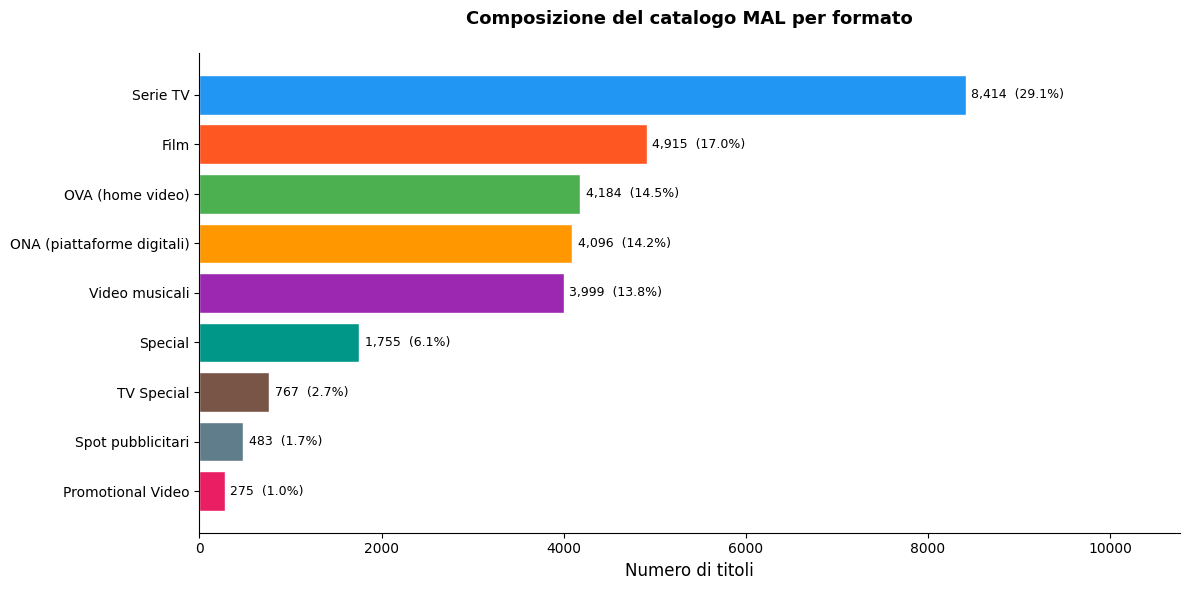

In [3]:
plot_type_distribution(details)

Quattro formati su nove hanno un peso narrativo reale nella nostra analisi: **TV, Movie, OVA e ONA**. Gli altri cinque (Music, CM, PV, Special e TV Special) sono contenuti accessori o promozionali che non aggiungono significato alle domande che ci poniamo.

Sappiamo già cosa sono le serie TV e film. Vediamo a cosa si riferiscono OVA e ONA.

**OVA — Original Video Animation**
Contenuti prodotti direttamente per il mercato home video, senza passare dalla televisione né dal cinema.

**ONA — Original Net Animation**
La versione digitale dell'OVA: contenuti distribuiti direttamente su internet, senza passare da televisione, cinema o supporto fisico.

Da questo punto in poi, `details` è filtrato a questi quattro formati (21.609 titoli su 28.955).

Prima di proseguire, osserviamo come è cambiato il peso di questi formati nel tempo: la produzione anime si è evoluta non solo nei contenuti, ma anche nelle modalità di distribuzione, spinte dal progresso tecnologico e dalla diffusione del web.

In [10]:
plot_format_evolution(details)

details = filter_main_types(details)
details_ex, top_genres = explode_genres(details)

details filtrato: 21,609 titoli  →  ['TV', 'Movie', 'OVA', 'ONA']


### Gli anni '90: l'era dell'OVA e del supporto fisico

Negli anni '90' l'OVA è il formato dominante — con picchi di **124 titoli nel 1991** e **168 nel 2001** — mentre la TV si mantiene sotto i 60 titoli annui fino al 1997. Questa dominanza è il riflesso diretto del mercato del supporto fisico. Il VHS prima, il Laserdisc poi e il DVD a fine decennio rendevano l'OVA il formato ideale per la distribuzione, senza passare dalla rete televisiva.

### 2000–2010: internet arriva, l'ONA nasce

I primi ONA compaiono nel dataset nel **1998–1999**, quasi esperimenti isolati. La loro crescita rispecchia fedelmente la diffusione della connessione a internet: **6 nel 2000, 25 nel 2005, 54 nel 2009**. È il periodo in cui YouTube viene fondato (2005) in cui le prime piattaforme streaming iniziano a testare la distribuzione di contenuti animati.

La TV mantiene la popolarità: **232 titoli nel 2006, 261 nel 2010**. La digitalizzazione rende l'accesso più semplice ai contenuti via internet e la crescita della cultura anime al di fuori del Giappone.

### 2010–2019: lo streaming ridisegna il mercato

Il decennio successivo segna il sorpasso definitivo dell'ONA sull'OVA. L'ONA passa da **85 titoli nel 2011 a 294 nel 2017**, mentre l'OVA scende da **147 a 93** nello stesso periodo. Il turning point è intorno al **2013–2014**, quando Crunchyroll supera il milione di abbonati e Netflix inizia ad espandersi globalmente.

La TV rimane dominante con **376 titoli nel 2016**, il picco storico, ma l'ONA cresce abbastanza velocemente fino a raggiungerla. Il Film si mantiene abbastanza costante con **181–192 titoli tra 2017 e 2019**.

### 2020: il Covid spezza le linee in modo asimmetrico

Il **2020** è leggibile a colpo d'occhio sul grafico: tutte e quattro le linee scendono, ma con intensità molto diverse a seconda del formato.

| Formato | 2019 | 2020 | Calo |
|---------|------|------|------|
| **Movie** | 181 | 110 | **−39%** |
| **TV** | 326 | 312 | −4% |
| **ONA** | 321 | 317 | −1% |
| **OVA** | 62 | 64 | +3% |

Il Film è il formato più colpito: la chiusura delle sale cinematografiche in Giappone e nel mondo blocca le uscite pianificate e rimanda le produzioni in fase finale. La TV subisce ritardi nelle produzioni: studi di animazione chiusi, doppiatori in smart working, pipeline interrotte, etc. Alcune produzioni vengono semplicemente spostate alla stagione successiva.

L'ONA è quasi immune: **nativamente digitale**, non dipende da sale né da supply chain fisiche. La produzione può continuare da remoto con strumenti già in uso. In alcuni casi il Covid ha addirittura accelerato la scelta di distribuire contenuti originali sulle piattaforme invece che in TV.

### 2021–2024: il rimbalzo e il nuovo equilibrio

La ripresa non è uniforme. Il **2021** è paradossalmente l'anno peggiore per la TV (**263 titoli**, il minimo dal 2009): le produzioni bloccate nel 2020 non si recuperano tutte in un colpo, e i ritardi si propagano. Dal **2022 in poi la TV risale**, mentre ONA e Movie raggiungono un nuovo equilibrio stabile intorno a valori pre-Covid.

Il dato più significativo del periodo post-Covid è strutturale: **l'ONA ha stabilmente sorpassato la TV** dal 2018 in poi. Non è un effetto temporaneo. È la conferma che il mercato anime si è riorganizzato attorno alle piattaforme di streaming, lo stesso processo che, nel mondo della musica, ha portato dal CD allo streaming in meno di vent'anni.

## C'è stato un cambiamento in base ai generi?

In [5]:
plot_genre_pie(details_ex)

A colpo d'occhio, si vede una dominanza del genere comedy. Dobbiamo però tenere in considerazione che tanti titoli hanno più di un genere. Chi è cresciuto negli anni '90 sicuramente ricorderà un panorama dominato da titoli come Dragon Ball, Gundam, Evangelion, etc.

C'è stato negli anni un cambiamento nei gusti per quanto riguarda i generi?

Nel grafico che segue ogni barra rappresenta un genere e la sua lunghezza indica la quota percentuale sul totale degli anime prodotti in quell'anno. Vediamo come sono cambiate le percentuali nell'arco degli anni. Ci concentriamo sugli 8 generi più prevalenti.

In [6]:
plot_genre_animation(details, details_ex, top_genres)

Genere dominante prima del 1993: Comedy
Genere dominante dal 1993: Fantasy


Nell arco degli anni, si osserva un' oscillazione costante tra i diversi generi rivelando un pattern più sfumato di quello che ci si aspetta. I quattro generi protagonisti sono sempre gli stessi: Comedy, Fantasy, Action e Adventure che si scambiano tra loro.

Comedy domina quasi ininterrottamente dal 1990 al 2018: ventotto anni in testa, con un'unica eccezione nel **1993**, quando Fantasy si prende il primo posto per un anno solo prima di cederlo di nuovo. **2019 è l'anno del primo sorpasso vero**: Fantasy supera Comedy per la prima volta a **22.3% contro 22.2%**, praticamente un pareggio.

La svolta definitiva arriva nel **2023–2024**: Fantasy si attesta al primo posto, ma la vera novità è che **Action sale al secondo posto** e Comedy scende al terzo per la prima volta in trent'anni.

L'unico genere diverso da questi 4 che nell'arco degli anni ha avuto dei picchi è Drama che negli anni **1993, 2000, 2004 e 2005** è salito nel top 4 prendendo il posto di Adventure.

## I gusti cambiano in base al genere?

Si dice spesso che uomini e donne guardino anime completamente diversi: Romance e Drama per le donne e Action e Adventure per gli uomini. Ma è uno stereotipo o c'è qualcosa di vero? E per quanto riguarda Non Binary?

Per rispondere, abbiamo incrociato il genere dichiarato dagli utenti (**Male**, **Female** e **Non Binary**) con i generi degli anime che hanno valutato. Per ogni genere anime, abbiamo calcolato quanto pesa sul totale guardato da ciascun gruppo. Il confronto mostra dove le preferenze divergono davvero e dove invece i tre gruppi guardano le stesse cose.

In [7]:
plot_gender_genres(ratings, profiles, details_ex, top_genres)

Il grafico ordina i generi per peso percentuale femminile decrescente, e la sequenza non è casuale: svela dove le preferenze divergono davvero e dove invece i tre gruppi guardano le stesse cose.

**Romance: lo stereotipo che non regge**
Il dato più sorprendente del grafico è proprio questo: Romance ha quote simili tra Male e Female. Lo stereotipo — le donne guardano romance, gli uomini no — non trova conferma nei numeri. Una possibile spiegazione è che il genere Romance su MAL raramente esiste da solo: è quasi sempre abbinato a Comedy o Drama in titoli che attraggono un pubblico ampio indipendentemente dal genere. *Toradora*, *Oregairu*, *Kaguya-sama* hanno fanbase miste, e il dato lo riflette.

**Drama: Female sopra, ma il gap è contenuto**
Drama mostra un leggero vantaggio femminile, più in linea con le aspettative. Titoli come *Violet Evergarden* e *Your Lie in April* hanno costruito un fanbase femminile fedele, ma il Drama in anime spazia abbastanza da includere anche titoli con pubblico maschile (*Fullmetal Alchemist*, *Vinland Saga*). Il gap c'è, ma non è il più ampio del grafico.

**Boys Love e Girls Love: entrambi a predominanza femminile**
BL e GL condividono lo stesso pattern: entrambi hanno una quota Female superiore a Male, anche se con intensità diversa. Boys Love — storie romantiche tra uomini — mostra il gap più marcato: il pubblico BL è storicamente composto da donne, non dagli uomini che vi appaiono, ed è un fenomeno ben documentato nella cultura manga e anime. Girls Love segue la stessa direzione ma con un divario più contenuto — il genere attrae comunque più Female che Male, smentendo l'assunzione che le storie tra donne siano pensate per un pubblico maschile. Il gruppo Non-Binary mostra su entrambi i generi quote comparabili o superiori al gruppo Female, suggerendo una relazione più aperta con narrazioni che escono dalla narrativa eteronormativa.

**Mystery, Suspense, Horror: il thriller è meno polarizzato del previsto**
Questi tre generi mostrano un divario di genere meno netto di quanto ci si aspetterebbe. Female è leggermente sopra, ma il gap è piccolo. Titoli come *Death Note*, *Another* e *Higurashi* hanno un pubblico trasversale, e i dati lo confermano: dove la narrativa si concentra sulla tensione e sulla risoluzione del mistero, i tre gruppi convergono.

**Action, Comedy, Fantasy, Adventure: il cuore dello shounen**
Questi quattro generi rappresentano il nucleo della produzione anime tradizionalmente maschile, e il gap si vede chiaramente. Action e Adventure sono i più sbilanciati: riflettono decenni di titoli shounen — *Naruto*, *One Piece*, *Dragon Ball* — pensati esplicitamente per un pubblico giovane maschile. Fantasy include l'isekai, che ha un fanbase prevalentemente maschile. Comedy, pur essendo il genere più universale dell'intero catalogo, rimane leggermente più consumato dal gruppo Male, probabilmente perché Comedy è spesso il genere secondario dei grandi shounen e ne segue il pubblico di riferimento.

**Ecchi, Hentai, Erotica: lo stereotipo regge solo in parte**
Lo stereotipo vuole questi tre generi come territorio esclusivamente maschile. I numeri raccontano una storia più articolata. Ecchi è l'unico dei tre dove Male è effettivamente il gruppo più alto, ma Female non è affatto marginale e Non-Binary si colloca nel mezzo. Il genere è sbilanciato verso Male, ma la differenza non è molto grande. Hentai ribalta completamente le aspettative: è Non-Binary il gruppo con la quota più alta, seguito da Male e poi Female. La differenza tra i tre gruppi è contenuta e lo stereotipo del consumatore maschile dominante non trova conferma nei dati. Erotica va ancora oltre: Female supera sia Non-Binary che Male. È il gruppo maschile a registrare la quota più bassa dei tre.

**Quello che lo stereotipo coglie e quello che manca**
 Lo stereotipo ha una base reale su Action e Adventure, quasi nulla su Romance. Il resto del grafico è più sfumato di quanto ci si aspetti: su Sci-Fi, Slice of Life, Supernatural e Sports i tre gruppi guardano praticamente le stesse cose. Dove i gusti divergono, divergono per una ragione precisa: decenni di produzione con un target demografico esplicito. Togliendo quella variabile storica, i tre profili si assomigliano molto più di quanto lo stereotipo lasci intuire.


## I gusti cambiano con l'età?

I Boomer e la Gen X hanno scoperto il medium in un'epoca di catalogo limitato, con titoli come Astro Boy, Lupin III. I Millennial sono cresciuti con Dragon Ball Z e Sailor Moon e la Gen Z con My Hero Academia e Demon Slayer. Sembra naturale ipotizzare che queste esperienze formative così diverse abbiano plasmato gusti strutturalmente differenti per ogni generazione.

Per testare questa ipotesi, abbiamo classificato gli utenti in quattro generazioni in base all'anno di nascita: Boomer (1946–1964), Gen X (1965–1980), Millennial (1981–1996), Gen Z (1997–2012) e abbiamo analizzato la distribuzione dei generi anime guardati da ciascun gruppo.

In [8]:
plot_generation_radar(ratings, profiles, details_ex, top_genres)

Lo spider chart rivela che i grafici per ogni generazione sono quasi sovrapponibili, con differenze evidenti sui generi Sci-Fi, Action, Fantasy e Suspense.

**Boomer: catalogo anni '70–'80**
Il profilo riflette ciò che era disponibile: Drama pesante, poche categorie action mainstream. Titoli come *Astro Boy*, *Galaxy Express 999*, *Lupin III*, anime pensati per la TV giapponese, con narrazioni lente e temi sociali. La distribuzione era quasi esclusivamente televisiva, il catalogo ristretto e il pubblico globale quasi inesistente.

**Gen X: anni '80–'90 - l'era del VHS e della Sci-Fi**
Confrontando Boomer e Gen X si nota che i Gen X guardano più Comedy, Sci-Fi, Adventure e Hentai, ma meno Drama, Fantasy, Suspense e Mystery. Il picco di Sci-Fi riflette il decennio d'oro del genere: *Gundam*, *Evangelion*, *Ghost in the Shell*, *Akira*, anime che hanno ridefinito la fantascienza animata. Il VHS prima e il Laserdisc poi hanno reso accessibili gli OVA, inclusi contenuti per adulti, il che spiega la quota più alta di Hentai rispetto alle generazioni successive.

**Millennial: anni '90–2000 - lo shounen e i fansub**
Spostandoci sui Millennial, il grafico è quasi identico a quello della generazione precedente, con un calo su Drama, Sci-Fi e Hentai ma un aumento su Romance, Action, Fantasy e Suspense. L'ascesa di Action e Fantasy coincide con la dominanza degli shounen: *Dragon Ball Z*, *Naruto*, *One Piece*, *Bleach*. Il Romance cresce con *Sailor Moon* e *Cardcaptor Sakura* che normalizzano il genere fuori dal Giappone. I fansub e il peer-to-peer ampliano l'accesso globale. Hentai cala perché il mercato si diversifica e i contenuti espliciti migrano su piattaforme dedicate.

**Gen Z: anni 2010–oggi - streaming e l'esplosione dell'isekai**
Millennial e Gen Z hanno sagome quasi sovrapponibili. I Gen Z mostrano un calo su Sci-Fi e Comedy, ma un aumento su Drama, Action, Fantasy e Suspense. Il calo della Sci-Fi è strutturale: Fantasy e Isekai hanno assorbito lo spazio dei "mondi alternativi" senza astronavi, *Sword Art Online*, *Re:Zero*, *Mushoku Tensei*. Il picco di Suspense riflette il successo di *Attack on Titan* e *Jujutsu Kaisen*. Crunchyroll e Netflix hanno globalizzato l'accesso e l'algoritmo ha standardizzato i consumi verso i generi più prodotti.

**Tendenza trasversale: il calo di Sci-Fi e Hentai**
Su larga scala si nota un calo progressivo di Sci-Fi e Hentai nel tempo. Il primo non è solo generazionale ma anche industriale: la produzione di Sci-Fi è calata in percentuale dal 2010 in poi, mentre Fantasy ed Isekai esplodevano. Le generazioni più giovani hanno trovato semplicemente meno Sci-Fi nel catalogo disponibile mentre crescevano. I Boomer rimangono la generazione più distante: la loro sagoma è la più piccola e distribuita diversamente, riflesso di un catalogo storicamente diverso e di preferenze formatesi prima che il mercato anime diventasse globale.

## La mappa geografica dei gusti: ogni paese ha il suo genere preferito?

Dopo aver visto che uomini e donne guardano anime più simili di quanto si pensi, e che le generazioni convergono quasi tutte sugli stessi generi, rimane una domanda aperta: la geografia conta? Per rispondere, abbiamo preso i 22 paesi presenti su MAL e misurato, per ciascuno, quanto si discosta dalla media globale su ogni genere. La mappa che segue mostra il risultato: il colore di ogni paese indica il genere in cui quella community si distingue di più dal resto del mondo.


In [9]:
plot_country_map(ratings, profiles, details_ex, top_genres)

A colpo d'occhio dalla mappa sembra che ci siano grandi differenze tra paesi. Ma i numeri raccontanp un altra storia: gli scostamenti dalla media globale sono tutti compresi tra +0.03% e +0.18%, differenze reali ma contenute. Nessun paese ha un profilo radicalmente diverso dagli altri.

**Comedy:**
È il colore più diffuso. Sei paesi su ventidue mostrano Comedy come genere più distintivo: Brasile, India, Italia, Corea del Sud, Thailandia e Regno Unito. È il risultato più comune sulla mappa e il meno sorprendente in quanto comedy è il genere più prodotto globalmente.

**Action:**
Argentina, Australia, Turchia e Vietnam condividono Action come tratto distintivo. Nonostante si tratti di paesi geograficamente distanti e culturalmente diversi, hanno in comune comunity giovani dove titoli shounen come *Dragon Ball*, *Naruto*, *One Piece* hanno avuto un ruolo centrale nell'introdurre il medium.

**Drama:**
Cina, Germania, Indonesia e Messico convergono su Drama come genere distintivo. Anche in questo caso si tratta di paesi culturalmente lontani che mostrano lo stesso segnale.

**Romance:**
Canada e Sudafrica sono gli unici due paesi sulla mappa con Romance come genere distintivo — e sono anche geograficamente agli antipodi. Il Sudafrica mostra lo scostamento più alto dei due (+0.13%), con Fantasy al secondo posto. Il Canada si ferma a +0.09%, con Action subito dietro. Sono community relativamente piccole rispetto ai grandi mercati, il che può amplificare il peso di pochi titoli molto seguiti.

**I tre casi unici**
Tre paesi non condividono il loro genere dominante con nessun altro sulla mappa:
- **Spagna → Sci-Fi**: unico paese europeo dove la fantascienza è il tratto più distintivo, con Fantasy e Adventure a seguire.
- **Egitto → Suspense**: la community egiziana si distingue per una quota di thriller superiore alla media, con Action al secondo posto, un profilo compatibile con il grande successo di *Death Note* e *Attack on Titan* nella regione.
- **Francia → Fantasy**: unico paese con Fantasy come genere di punta, con Ecchi al secondo posto. Riflette probabilmente l'impatto degli isekai sul pubblico francese, che ha una delle community anime più grandi d'Europa.

**Giappone, Filippine e Stati Uniti: Hentai come segnale distintivo**
Tre paesi mostrano Hentai come genere con la deviazione positiva più alta. Si tratta di tre delle community anime più consolidate al mondo — paesi dove il medium è presente da decenni e il catalogo viene consumato in modo più ampio e meno filtrato rispetto ai mercati dove l'anime è un fenomeno più recente.

**Cosa dice davvero la mappa**
La mappa disegna un'immagine più sfumata di quanto ci si aspettasse. I gusti non si polarizzano per continente né per area linguistica: Comedy domina nelle community più diverse, Action in quelle più giovani, Drama nei mercati con una tradizione narrativa più lunga. I casi davvero unici come Spagna con Sci-Fi, Egitto con Suspense e Francia con Fantasy sono eccezioni che confermano la regola: la geografia introduce variazione, ma non la struttura. Il dato più robusto non è quale genere domina in quale paese, ma quanto poco i profili si discostino tra loro. Il pubblico anime globale è più omogeneo di quanto la sua distribuzione geografica lasci immaginare.



## Quello che i dati ci dicono sulla società che guarda anime

Tre variabili demografiche, tre risposte che ridisegnano la mappa del pubblico anime.

Il genere dell'utente divide meno di quanto si pensi: le differenze esistono, ma sono circoscritte a poche categorie. La generazione divide ancora meno: Millennial e Gen Z guardano anime con proporzioni quasi identiche per genere, e la Gen X si distingue solo per l'eredità di un catalogo storicamente diverso. La geografia, invece, introduce più variazione.

Sullo sfondo di tutto questo c'è la trasformazione della produzione: un'industria che ha trovato nel Fantasy e nell'Isekai in particolare la sua formula dominante, e che non è tornata indietro. Quella svolta non è casuale: coincide con l'espansione delle piattaforme digitali e con una domanda globale di contenuti seriali accessibili. Il mercato ha risposto a un bisogno che attraversa generazioni e generi.